# Dataset Description

This project uses a publicly available MRI brain tumor dataset containing four classes:

- Glioma Tumor
- Meningioma Tumor
- Pituitary Tumor
- No Tumor (healthy brain)

The dataset is organized into predefined training and testing folders.

In [1]:
import os

BASE_DIR = os.path.abspath("..")  # goes to project root

In [2]:
model_path = os.path.join(BASE_DIR, "models/classification/efficientnet_b0_best.pth")
image_path = os.path.join(BASE_DIR, "data/Testing/glioma/Te-gl_0010.jpg")
output_path = os.path.join(BASE_DIR, "outputs/gradcam.jpg")

In [9]:
import os

project_root = "/Users/bhavyavardhansingh/Downloads/DSA/Brain Tumor"
dataset_root = os.path.join(project_root, "archive")

train_path = os.path.join(dataset_root, "Training")
test_path  = os.path.join(dataset_root, "Testing")

print("Train Path:", train_path)
print("Test Path:", test_path)


Train Path: /Users/bhavyavardhansingh/Downloads/DSA/Brain Tumor/archive/Training
Test Path: /Users/bhavyavardhansingh/Downloads/DSA/Brain Tumor/archive/Testing


In [10]:
def count_images(folder_path):
    class_counts = {}
    for cls in os.listdir(folder_path):
        cls_path = os.path.join(folder_path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len(os.listdir(cls_path))
    return class_counts

train_counts = count_images(train_path)
test_counts = count_images(test_path)

print("Training Set Distribution:")
for k, v in train_counts.items():
    print(k, ":", v)

print("\nTesting Set Distribution:")
for k, v in test_counts.items():
    print(k, ":", v)


Training Set Distribution:
pituitary : 1457
notumor : 1595
glioma : 1321
meningioma : 1339

Testing Set Distribution:
pituitary : 300
notumor : 405
glioma : 300
meningioma : 306


### Dataset Distribution Summary

| Class | Training Images | Testing Images | Total |
|------|------|------|------|
| Pituitary | 1457 | 300 | 1757 |
| No Tumor | 1595 | 405 | 2000 |
| Glioma | 1321 | 300 | 1621 |
| Meningioma | 1339 | 306 | 1645 |
| **Total** | **5712** | **1311** | **7023** |

In [11]:
# ==============================================================
# STEP 1 — REMOVE EXACT DUPLICATE IMAGES USING SHA256 HASHING
# ==============================================================

import os
import hashlib
from tqdm import tqdm

def file_hash(filepath):
    """
    Computes SHA256 hash of a file.
    Used to detect exact duplicate images.
    """
    hasher = hashlib.sha256()
    with open(filepath, 'rb') as f:
        buf = f.read()
        hasher.update(buf)
    return hasher.hexdigest()


def remove_duplicates(folder_path):
    """
    Scans all images inside folder_path recursively
    and removes exact duplicate files.
    """
    print(f"\nScanning for duplicates in: {folder_path}")
    
    hashes = {}
    duplicates = []

    for root, dirs, files in os.walk(folder_path):
        for file in tqdm(files):
            filepath = os.path.join(root, file)
            filehash = file_hash(filepath)

            if filehash in hashes:
                duplicates.append(filepath)
            else:
                hashes[filehash] = filepath

    print(f"\nTotal duplicates found: {len(duplicates)}")

    # Remove duplicates
    for dup in duplicates:
        os.remove(dup)

    print("Duplicate removal completed.\n")
    

# Apply to Training and Testing folders
remove_duplicates(train_path)
remove_duplicates(test_path)



Scanning for duplicates in: /Users/bhavyavardhansingh/Downloads/DSA/Brain Tumor/archive/Training


0it [00:00, ?it/s]
100%|██████████| 1339/1339 [00:00<00:00, 4409.36it/s]



Total duplicates found: 191
Duplicate removal completed.


Scanning for duplicates in: /Users/bhavyavardhansingh/Downloads/DSA/Brain Tumor/archive/Testing


0it [00:00, ?it/s]
100%|██████████| 306/306 [00:00<00:00, 4090.43it/s]


Total duplicates found: 27
Duplicate removal completed.



In [12]:
print("\nDataset After Duplicate Removal")

train_counts_clean = count_images(train_path)
test_counts_clean = count_images(test_path)

print("Training Set Distribution:")
for k, v in train_counts_clean.items():
    print(k, ":", v)

print("\nTesting Set Distribution:")
for k, v in test_counts_clean.items():
    print(k, ":", v)


Dataset After Duplicate Removal
Training Set Distribution:
pituitary : 1445
notumor : 1422
glioma : 1321
meningioma : 1333

Testing Set Distribution:
pituitary : 300
notumor : 381
glioma : 299
meningioma : 304


## Dataset Distribution After Duplicate Removal

| Class | Training Images | Testing Images | Total |
|------|------|------|------|
| Pituitary | 1445 | 300 | 1745 |
| No Tumor | 1422 | 381 | 1803 |
| Glioma | 1321 | 299 | 1620 |
| Meningioma | 1333 | 304 | 1637 |
| **Total** | **5521** | **1284** | **6805** |

A total of **218 duplicate images were removed** during the data cleaning stage, resulting in a dataset of **6805 unique MRI images**.

### Dataset After Duplicate Removal

After applying SHA256-based duplicate detection, the dataset was scanned again to verify that all duplicate images were removed.

The statistics confirm that the dataset now contains only unique images, ensuring fair training and evaluation.

In [22]:
# ==============================================================
# STEP 2 — DATA PREPROCESSING TRANSFORMS
# Using torchvision.transforms for resizing, augmentation,
# tensor conversion, and normalization (ImageNet standard)
# ==============================================================

from torchvision import transforms

# Training transformations (includes augmentation)
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),      # Standard input size for pretrained CNNs
    transforms.RandomHorizontalFlip(),  # Improves generalization
    transforms.RandomRotation(10),      # Small rotation augmentation
    transforms.ToTensor(),              # Convert image to PyTorch tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],     # ImageNet mean
        std=[0.229, 0.224, 0.225]       # ImageNet std
    )
])

# Validation & Test transformations (NO augmentation)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms defined successfully.")


Transforms defined successfully.


In [23]:
# Verify PyTorch and Torchvision installation

import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.8.0
Torchvision version: 0.23.0
CUDA available: False


In [24]:
# ============================================================
# STEP 3 — DEVICE CONFIGURATION
# Supports CUDA (NVIDIA), MPS (Apple Silicon), and CPU
# ============================================================

import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)


Using device: mps


In [25]:
# ============================================================
# STEP 4 — DEFINE PROJECT PATHS (LOCAL MACHINE - VS CODE)
# ============================================================

import os

# 🔹 Set your project root folder (adjust if needed)
project_root = "/Users/bhavyavardhansingh/Downloads/DSA/Brain Tumor"

# 🔹 Training and Testing folders
train_path = os.path.join(project_root, "archive", "Training")
test_path  = os.path.join(project_root, "archive", "Testing")

print("Training Path:", train_path)
print("Testing Path:", test_path)

# 🔹 Verify class folders
print("\nClasses inside Training:")
print(os.listdir(train_path))

print("\nClasses inside Testing:")
print(os.listdir(test_path))

Training Path: /Users/bhavyavardhansingh/Downloads/DSA/Brain Tumor/archive/Training
Testing Path: /Users/bhavyavardhansingh/Downloads/DSA/Brain Tumor/archive/Testing

Classes inside Training:
['pituitary', 'notumor', 'glioma', 'meningioma']

Classes inside Testing:
['pituitary', 'notumor', 'glioma', 'meningioma']


Using image: /Users/bhavyavardhansingh/Downloads/DSA/Brain Tumor/archive/Training/glioma/Tr-gl_1135.jpg


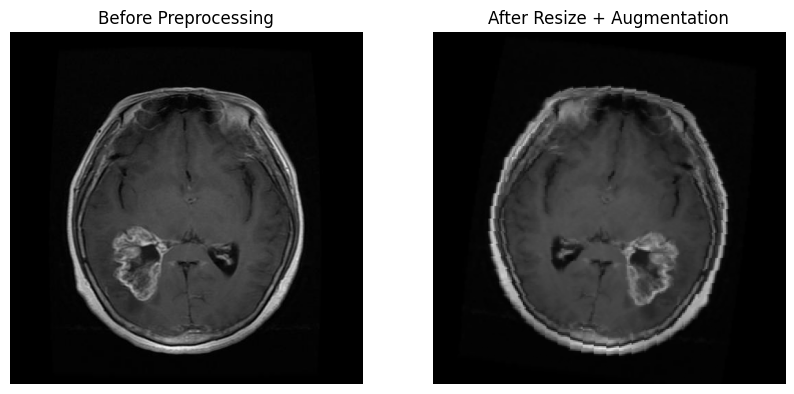

In [26]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# ---- Set folder ----
folder_path = "/Users/bhavyavardhansingh/Downloads/DSA/Brain Tumor/archive/Training/glioma"

# ---- Automatically pick first image ----
image_name = os.listdir(folder_path)[0]
sample_image_path = os.path.join(folder_path, image_name)

print("Using image:", sample_image_path)

# ---- Load image ----
original_image = Image.open(sample_image_path).convert("RGB")

# ---- Simple transform (no normalization) ----
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

processed_tensor = simple_transform(original_image)
processed_image = processed_tensor.permute(1, 2, 0)

# ---- Plot ----
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original_image)
plt.title("Before Preprocessing")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed_image)
plt.title("After Resize + Augmentation")
plt.axis("off")

plt.show()

In [27]:
# ============================================================
# STEP 5 — DATA PREPROCESSING TRANSFORMS
# Using torchvision.transforms
# ============================================================

from torchvision import transforms

# 🔹 ImageNet normalization (required for pretrained models)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# 🔹 Training Transform (includes augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),            # Standard input size
    transforms.RandomHorizontalFlip(),        # Mild augmentation
    transforms.RandomRotation(10),            # Small rotation (medical-safe)
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# 🔹 Testing Transform (NO augmentation)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

print("Transforms ready.")


Transforms ready.


In [28]:
# ============================================================
# STEP 6 — CREATE DATASETS & DATALOADERS
# Using torchvision.datasets.ImageFolder
# ============================================================

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

# 🔹 Load full training dataset
full_train_dataset = ImageFolder(train_path, transform=train_transform)

# 🔹 Create 80/20 Train-Validation split
val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 🔹 Important: Validation should NOT use augmentation
val_dataset.dataset.transform = test_transform

# 🔹 Load test dataset
test_dataset = ImageFolder(test_path, transform=test_transform)

# 🔹 Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", full_train_dataset.classes)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train size: 4417
Validation size: 1104
Test size: 1284


In [29]:
# ============================================================
# STEP 7 — CUSTOM CNN (BASELINE MODEL)
# Simple Convolutional Neural Network
# ============================================================

import torch.nn as nn

class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# 🔹 Initialize model
baseline_model = CustomCNN().to(device)

print("Baseline Custom CNN created successfully.")

Baseline Custom CNN created successfully.


In [30]:
# ============================================================
# STEP 8 — TRAIN BASELINE MODEL
# ============================================================

import torch.optim as optim
from tqdm import tqdm

def train_model(model, train_loader, val_loader, epochs=5, lr=1e-4):
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        # -------- Training --------
        model.train()
        train_correct = 0
        train_total = 0
        
        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        train_acc = 100 * train_correct / train_total
        
        # -------- Validation --------
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = 100 * val_correct / val_total
        
        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"Train Accuracy: {train_acc:.2f}%")
        print(f"Validation Accuracy: {val_acc:.2f}%")
    
    return model


# 🔹 Train baseline model
baseline_model = train_model(baseline_model, train_loader, val_loader)

100%|██████████| 139/139 [00:46<00:00,  3.00it/s]



Epoch [1/5]
Train Accuracy: 69.16%
Validation Accuracy: 76.27%


100%|██████████| 139/139 [00:52<00:00,  2.65it/s]



Epoch [2/5]
Train Accuracy: 82.30%
Validation Accuracy: 82.07%


100%|██████████| 139/139 [00:49<00:00,  2.83it/s]



Epoch [3/5]
Train Accuracy: 86.53%
Validation Accuracy: 84.42%


100%|██████████| 139/139 [00:40<00:00,  3.44it/s]



Epoch [4/5]
Train Accuracy: 88.88%
Validation Accuracy: 87.23%


100%|██████████| 139/139 [00:40<00:00,  3.46it/s]



Epoch [5/5]
Train Accuracy: 90.97%
Validation Accuracy: 88.32%


In [ ]:
# ============================================================
# Training Function
# ============================================================

import torch.optim as optim
from tqdm import tqdm

def train_model(model, train_loader, val_loader, epochs=5, lr=1e-4):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):

        model.train()
        train_correct = 0
        train_total = 0

        for images, labels in tqdm(train_loader):

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)

            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_acc = 100 * train_correct / train_total

        model.eval()

        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images, labels = images.to(device), labels.to(device)

                outputs = model(images)

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total

        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"Train Accuracy: {train_acc:.2f}%")
        print(f"Validation Accuracy: {val_acc:.2f}%")

    return model

In [32]:
# ============================================================
# TRAIN, SAVE, AND RELOAD BASELINE MODEL
# ============================================================

# Train the baseline model
baseline_model = train_model(
    baseline_model,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-3
)

# Save the trained model
torch.save(baseline_model.state_dict(), "custom_cnn_baseline.pth")
print("Baseline model trained and saved.")

# Reload the model for evaluation
baseline_model = CustomCNN(num_classes=4).to(device)

baseline_model.load_state_dict(
    torch.load("custom_cnn_baseline.pth", map_location=device)
)

baseline_model.eval()

print("Baseline model reloaded and ready for evaluation.")

100%|██████████| 139/139 [00:40<00:00,  3.43it/s]



Epoch [1/5]
Train Accuracy: 82.54%
Validation Accuracy: 83.51%


100%|██████████| 139/139 [00:40<00:00,  3.47it/s]



Epoch [2/5]
Train Accuracy: 90.02%
Validation Accuracy: 90.40%


100%|██████████| 139/139 [00:37<00:00,  3.68it/s]



Epoch [3/5]
Train Accuracy: 93.53%
Validation Accuracy: 90.22%


100%|██████████| 139/139 [00:39<00:00,  3.54it/s]



Epoch [4/5]
Train Accuracy: 95.18%
Validation Accuracy: 90.94%


100%|██████████| 139/139 [00:38<00:00,  3.61it/s]



Epoch [5/5]
Train Accuracy: 97.49%
Validation Accuracy: 91.76%
Baseline model trained and saved.
Baseline model reloaded and ready for evaluation.


In [33]:
baseline_model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = baseline_model(images)


===== BASELINE CUSTOM CNN TEST PERFORMANCE =====
Accuracy: 0.9354
Precision (Macro): 0.9337
Recall (Macro): 0.9324
F1 Score (Macro): 0.9327
ROC-AUC (OvR): 0.9886


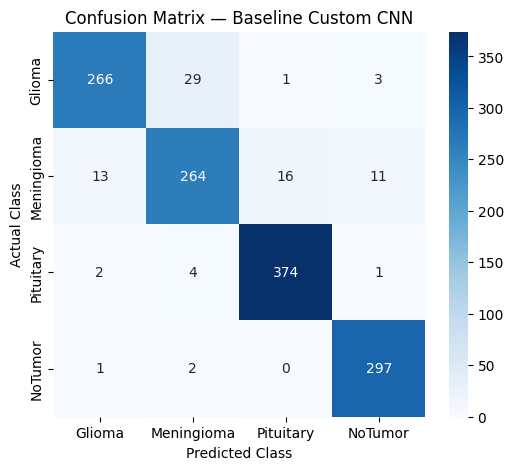


===== DETAILED CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

      glioma       0.94      0.89      0.92       299
  meningioma       0.88      0.87      0.88       304
     notumor       0.96      0.98      0.97       381
   pituitary       0.95      0.99      0.97       300

    accuracy                           0.94      1284
   macro avg       0.93      0.93      0.93      1284
weighted avg       0.93      0.94      0.93      1284



In [38]:
# ============================================================
# STEP — Evaluate Baseline Model on TEST SET
# Calculates Accuracy, Precision, Recall, F1, ROC-AUC
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []
all_probs = []

baseline_model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = baseline_model(images)

        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())


all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# =============================
# Calculate Metrics
# =============================

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")
f1 = f1_score(all_labels, all_preds, average="macro")
roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")

print("\n===== BASELINE CUSTOM CNN TEST PERFORMANCE =====")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1 Score (Macro): {f1:.4f}")
print(f"ROC-AUC (OvR): {roc_auc:.4f}")


# ============================================================
# FORMATTED CONFUSION MATRIX
# ============================================================

labels = ["Glioma", "Meningioma", "Pituitary", "NoTumor"]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix — Baseline Custom CNN")

plt.show()
    
# =============================
# Classification Report
# =============================

print("\n===== DETAILED CLASSIFICATION REPORT =====\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

---

## Baseline Model — Key Findings

1. **Strong baseline performance:**  
   The Custom CNN baseline achieved **93.54% accuracy** on the test dataset, demonstrating that a simple convolutional architecture can effectively learn tumor-related patterns from MRI images.

2. **Highest detection performance for pituitary tumors:**  
   The confusion matrix shows **374 correct predictions for pituitary tumors**, resulting in a **recall 0.97**, indicating that pituitary tumors have distinct visual features that the model can easily recognize.

3. **Reliable identification of normal brain scans:**  
   The model correctly classified **297 no-tumor images**, achieving a **recall of approximately 0.98**, which shows strong capability in distinguishing healthy brain images from tumor cases.

4. **Most misclassifications occur between glioma and meningioma:**  
   The confusion matrix reveals that **29 glioma samples were predicted as meningioma and 13 meningioma samples as glioma**, suggesting visual similarity between these tumor types in MRI scans.

5. **Balanced dataset contributed to stable evaluation metrics:**  
   Since the dataset contains similar numbers of samples for each class, the **macro average and weighted average metrics are nearly identical**, indicating consistent performance across classes.

---

## Baseline Model Limitation

The Custom CNN achieved **94% accuracy**, but the remaining **6% misclassification error** is primarily due to the model’s **limited depth, lack of pretrained feature representations, and visual similarity between certain tumor types (especially glioma and meningioma).**

---
---

In [40]:
# ============================================================
# STEP — Load Pretrained ResNet50
# Using torchvision.models with ImageNet weights
# ============================================================

from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

# Load pretrained weights
weights = ResNet50_Weights.IMAGENET1K_V2
resnet_model = resnet50(weights=weights)

# Replace final fully connected layer
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 4)

# Move to device
resnet_model = resnet_model.to(device)

print("ResNet50 loaded and modified successfully.")


ResNet50 loaded and modified successfully.


In [41]:
# ============================================================
# STEP — Train ResNet50 (Fine-Tuning)
# ============================================================

resnet_model.train()

trained_resnet = train_model(
    resnet_model,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-4   # lower LR for transfer learning
)

# Save trained model
torch.save(trained_resnet.state_dict(), "resnet50_finetuned.pth")

print("ResNet50 trained and saved successfully.")


100%|██████████| 139/139 [03:27<00:00,  1.49s/it]



Epoch [1/5]
Train Accuracy: 88.84%
Validation Accuracy: 94.02%


100%|██████████| 139/139 [03:10<00:00,  1.37s/it]



Epoch [2/5]
Train Accuracy: 97.83%
Validation Accuracy: 96.74%


100%|██████████| 139/139 [03:15<00:00,  1.41s/it]



Epoch [3/5]
Train Accuracy: 99.34%
Validation Accuracy: 97.64%


100%|██████████| 139/139 [03:13<00:00,  1.40s/it]



Epoch [4/5]
Train Accuracy: 99.34%
Validation Accuracy: 97.19%


100%|██████████| 139/139 [03:12<00:00,  1.38s/it]



Epoch [5/5]
Train Accuracy: 99.14%
Validation Accuracy: 97.19%
ResNet50 trained and saved successfully.



===== RESNET50 TEST PERFORMANCE =====
Accuracy: 0.9704
Precision (Macro): 0.9702
Recall (Macro): 0.9686
F1-Score (Macro): 0.9690
ROC-AUC (OvR): 0.9982


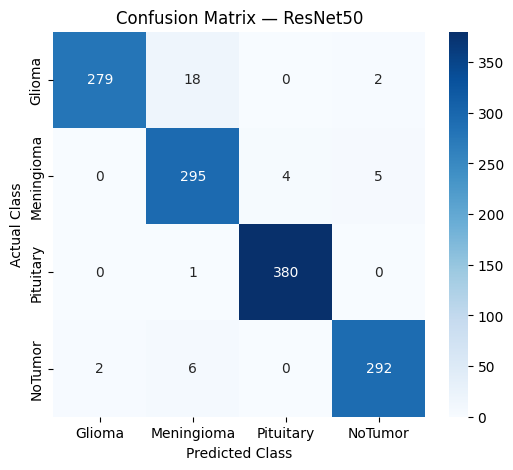


Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.93      0.96       299
  meningioma       0.92      0.97      0.95       304
     notumor       0.99      1.00      0.99       381
   pituitary       0.98      0.97      0.97       300

    accuracy                           0.97      1284
   macro avg       0.97      0.97      0.97      1284
weighted avg       0.97      0.97      0.97      1284



In [45]:
# ============================================================
# STEP — Evaluate ResNet50 on TEST SET
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Reload saved weights (to ensure reproducibility)
resnet_model = resnet50(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 4)

resnet_model.load_state_dict(
    torch.load("resnet50_finetuned.pth", map_location=device)
)

resnet_model = resnet_model.to(device)
resnet_model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)

        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# ===============================
# Calculate Metrics
# ===============================

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")
f1 = f1_score(all_labels, all_preds, average="macro")
roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")

print("\n===== RESNET50 TEST PERFORMANCE =====")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1-Score (Macro): {f1:.4f}")
print(f"ROC-AUC (OvR): {roc_auc:.4f}")

# ===============================
# Heatmap Visualization
# ===============================

labels = ["Glioma", "Meningioma", "Pituitary", "NoTumor"]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix — ResNet50")

plt.show()

# ===============================
# Confusion Matrix
# ===============================

print("\nDetailed Classification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=full_train_dataset.classes
    )
)


---

## ResNet50 Model — Key Findings

- **High overall performance:** The fine-tuned ResNet50 achieved **97.04% test accuracy**, demonstrating strong generalization on the MRI tumor classification task.

- **Balanced class performance:** A **macro F1-score of 0.9690** indicates that the model performs consistently across all four tumor classes.

- **Excellent class separability:** The **ROC-AUC score of 0.9982** shows that the model can effectively distinguish between different tumor categories.

- **Clear improvement over baseline:** ResNet50 improves performance by **about 4% over the custom CNN baseline (94% → 97.04%)**, highlighting the benefit of transfer learning.

- **Reliable tumor detection:** The confusion matrix shows **very low false negatives in tumor classes**, indicating strong detection capability for clinical support.

- **Minor class confusion:** A slightly lower recall for **glioma** suggests occasional confusion with **meningioma** due to similar MRI features.

- **Transfer learning effectiveness:** Using a pretrained ResNet50 significantly improves feature extraction compared to training a CNN from scratch.

---

## ResNet50 Model — Limitation

Although ResNet50 achieves high accuracy, **some misclassification between visually similar tumor types (especially glioma and meningioma) still occurs**, indicating the need for more specialized feature learning or additional medical data.

---
---

In [46]:
# ============================================================
# LOAD DENSENET121 (Transfer Learning Model)
# Using pretrained ImageNet weights
# ============================================================

from torchvision.models import densenet121, DenseNet121_Weights
import torch.nn as nn

weights = DenseNet121_Weights.IMAGENET1K_V1
model = densenet121(weights=weights)

# Replace classifier for 4 tumor classes
model.classifier = nn.Linear(model.classifier.in_features, 4)

model = model.to(device)

print("DenseNet121 loaded and modified successfully.")


DenseNet121 loaded and modified successfully.


In [47]:
# ============================================================
# TRAIN DENSENET121
# ============================================================

trained_model = train_model(
    model,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-4
)

# Save the trained model
torch.save(trained_model.state_dict(), "densenet121_model.pth")

print("DenseNet121 trained and saved successfully.")


100%|██████████| 139/139 [03:38<00:00,  1.57s/it]



Epoch [1/5]
Train Accuracy: 91.24%
Validation Accuracy: 97.37%


100%|██████████| 139/139 [03:27<00:00,  1.50s/it]



Epoch [2/5]
Train Accuracy: 98.37%
Validation Accuracy: 97.01%


100%|██████████| 139/139 [03:15<00:00,  1.41s/it]



Epoch [3/5]
Train Accuracy: 99.71%
Validation Accuracy: 97.46%


100%|██████████| 139/139 [03:12<00:00,  1.39s/it]



Epoch [4/5]
Train Accuracy: 99.37%
Validation Accuracy: 96.74%


100%|██████████| 139/139 [03:10<00:00,  1.37s/it]



Epoch [5/5]
Train Accuracy: 99.66%
Validation Accuracy: 97.64%
DenseNet121 trained and saved successfully.



===== DENSENET121 TEST PERFORMANCE =====
Accuracy: 0.9805
Precision (Macro): 0.9799
Recall (Macro): 0.9797
F1-Score (Macro): 0.9795
ROC-AUC (OvR): 0.9992


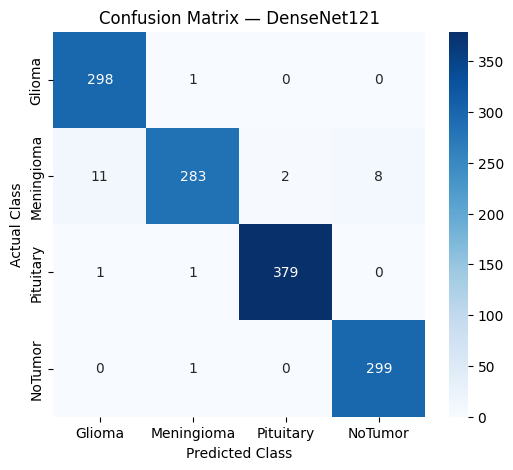


===== DETAILED CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      glioma       0.96      1.00      0.98       299
  meningioma       0.99      0.93      0.96       304
     notumor       0.99      0.99      0.99       381
   pituitary       0.97      1.00      0.99       300

    accuracy                           0.98      1284
   macro avg       0.98      0.98      0.98      1284
weighted avg       0.98      0.98      0.98      1284



In [48]:
# ============================================================
# EVALUATE DENSENET121 ON TEST SET
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Reload saved model to ensure reproducibility
model = densenet121(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, 4)

model.load_state_dict(torch.load("densenet121_model.pth", map_location=device))

model = model.to(device)
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())


all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# =============================
# Calculate Metrics
# =============================

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")
f1 = f1_score(all_labels, all_preds, average="macro")
roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")

print("\n===== DENSENET121 TEST PERFORMANCE =====")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1-Score (Macro): {f1:.4f}")
print(f"ROC-AUC (OvR): {roc_auc:.4f}")


# =============================
# Confusion Matrix (Heatmap)
# =============================

cm = confusion_matrix(all_labels, all_preds)

labels = ["Glioma", "Meningioma", "Pituitary", "NoTumor"]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix — DenseNet121")

plt.show()


# =============================
# Classification Report
# =============================

print("\n===== DETAILED CLASSIFICATION REPORT =====")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=full_train_dataset.classes
    )
)

---

## DenseNet121 Model — Key Findings

- **High classification performance:** DenseNet121 achieved **98.05% test accuracy**, demonstrating excellent generalization on the brain MRI tumor classification task.

- **Balanced multi-class performance:** A **macro F1-score of 0.9795** indicates that the model performs consistently across all four classes without favoring any particular tumor category.

- **Excellent class separability:** The **ROC-AUC score of 0.9992** shows that DenseNet121 can distinguish between tumor types with very high confidence.

- **Better feature preservation than ResNet50:** DenseNet121 slightly outperforms ResNet50 in ROC-AUC because its **dense connections reuse feature maps from all previous layers**, allowing the model to preserve subtle texture and structural details important in MRI images.

- **Very low misclassification across tumor classes:** The confusion matrix shows minimal cross-class confusion, indicating reliable tumor detection and classification.

- **Effective transfer learning:** The combination of **ImageNet pretrained weights and dense feature reuse** enables the model to learn complex medical image patterns efficiently.

---

## DenseNet121 Model — Limitation

Despite its strong performance, DenseNet121 **still shows minor confusion between visually similar tumor types such as glioma and meningioma**, and its deeper architecture also increases computational complexity compared to simpler CNN models.

---
---

In [49]:
# ============================================================
# LOAD AND MODIFY EFFICIENTNET-B0 (Transfer Learning Model)
# Using torchvision.models with ImageNet pretrained weights
# ============================================================

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

# Load pretrained weights (ImageNet)
weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = efficientnet_b0(weights=weights)

# Replace classifier for 4-class output
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 4)

model = model.to(device)

print("EfficientNetB0 loaded and modified successfully.")


EfficientNetB0 loaded and modified successfully.


In [50]:
# ============================================================
# TRAIN EFFICIENTNET-B0
# Using transfer learning with fine-tuning
# ============================================================

trained_model = train_model(
    model,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-4   # Lower LR for pretrained models (more stable)
)

# Save trained model
torch.save(trained_model.state_dict(), "efficientnet_b0_best.pth")

print("EfficientNetB0 trained and saved successfully.")


100%|██████████| 139/139 [02:27<00:00,  1.06s/it]



Epoch [1/5]
Train Accuracy: 86.42%
Validation Accuracy: 94.57%


100%|██████████| 139/139 [02:14<00:00,  1.04it/s]



Epoch [2/5]
Train Accuracy: 95.68%
Validation Accuracy: 97.10%


100%|██████████| 139/139 [02:15<00:00,  1.03it/s]



Epoch [3/5]
Train Accuracy: 98.28%
Validation Accuracy: 96.83%


100%|██████████| 139/139 [02:19<00:00,  1.00s/it]



Epoch [4/5]
Train Accuracy: 98.80%
Validation Accuracy: 97.28%


100%|██████████| 139/139 [02:12<00:00,  1.05it/s]



Epoch [5/5]
Train Accuracy: 99.14%
Validation Accuracy: 98.10%
EfficientNetB0 trained and saved successfully.


===== EFFICIENTNET-B0 TEST PERFORMANCE =====
Accuracy: 0.9836
Precision (Macro): 0.9838
Recall (Macro): 0.9828
F1-Score (Macro): 0.9833
ROC-AUC (OvR): 0.9995


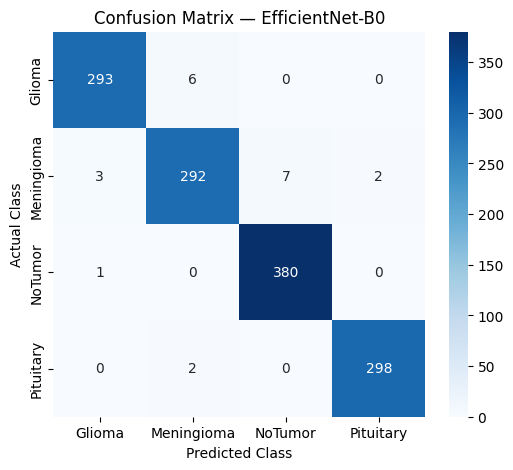


Detailed Classification Report:
              precision    recall  f1-score   support

      Glioma       0.99      0.98      0.98       299
  Meningioma       0.97      0.96      0.97       304
     NoTumor       0.98      1.00      0.99       381
   Pituitary       0.99      0.99      0.99       300

    accuracy                           0.98      1284
   macro avg       0.98      0.98      0.98      1284
weighted avg       0.98      0.98      0.98      1284



In [51]:
# ============================================================
# EVALUATE EFFICIENTNET-B0 ON TEST SET
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load best saved model (safety step)
model.load_state_dict(torch.load("efficientnet_b0_best.pth", map_location=device))
model = model.to(device)
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# ===============================
# Metrics
# ===============================

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")
f1 = f1_score(all_labels, all_preds, average="macro")
roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")

print("===== EFFICIENTNET-B0 TEST PERFORMANCE =====")
print("Accuracy:", round(accuracy, 4))
print("Precision (Macro):", round(precision, 4))
print("Recall (Macro):", round(recall, 4))
print("F1-Score (Macro):", round(f1, 4))
print("ROC-AUC (OvR):", round(roc_auc, 4))


# ===============================
# Confusion Matrix Heatmap
# ===============================

cm = confusion_matrix(all_labels, all_preds)

class_names = ['Glioma', 'Meningioma', 'NoTumor', 'Pituitary']

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix — EfficientNet-B0")

plt.show()


# ===============================
# Classification Report
# ===============================

print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

---

## EfficientNet-B0 Model — Key Findings

- **Highest overall performance:** EfficientNet-B0 achieved **98.36% test accuracy**, making it the best-performing model among the evaluated architectures.

- **Balanced multi-class classification:** A **macro F1-score of 0.9833** indicates strong and consistent performance across all four tumor classes.

- **Near-perfect class separability:** The **ROC-AUC score of 0.9995** demonstrates excellent ability to distinguish between tumor categories.

- **Minimal misclassification:** The confusion matrix shows **very few errors**, with most predictions concentrated along the diagonal, indicating reliable classification.

- **Strong detection of tumor classes:** High recall for **glioma, meningioma, and pituitary tumors** suggests the model is dependable for tumor identification.

- **Robust generalization:** EfficientNet-B0 maintains high accuracy while using fewer parameters, showing strong generalization capability on unseen MRI scans.

- **Best performance-efficiency trade-off:** Compared to ResNet50 and DenseNet121, EfficientNet-B0 delivers slightly better accuracy while remaining computationally efficient.

---

## Why EfficientNet-B0 Performs Better Than ResNet50 and DenseNet121

- **Compound scaling:** EfficientNet scales **network depth, width, and input resolution together**, allowing it to learn richer features without unnecessary parameter growth.

- **Better parameter efficiency:** It achieves higher accuracy with **fewer parameters**, reducing overfitting and improving generalization on moderate-sized datasets like this MRI dataset.

- **Improved feature extraction:** The architecture captures both **fine-grained textures and global structures** in MRI images more effectively than traditional CNN scaling strategies.

- **Optimized convolution blocks:** EfficientNet uses **MBConv blocks with squeeze-and-excitation attention**, enabling the network to focus on the most relevant tumor features.

---

## EfficientNet-B0 Model — Limitation

Despite its excellent performance, EfficientNet-B0 **still shows minor confusion between visually similar tumor types such as glioma and meningioma**, indicating that subtle MRI similarities remain challenging even for advanced architectures.

---
---

In [52]:
# ===============================================
# LOAD VISION TRANSFORMER (ViT-B/16)
# ===============================================

from torchvision.models import vit_b_16, ViT_B_16_Weights
import torch.nn as nn

# Load pretrained weights
weights = ViT_B_16_Weights.IMAGENET1K_V1
vit_model = vit_b_16(weights=weights)

# Replace classifier head
vit_model.heads.head = nn.Linear(vit_model.heads.head.in_features, 4)

vit_model = vit_model.to(device)

print("Vision Transformer loaded and modified successfully.")


Vision Transformer loaded and modified successfully.


In [53]:
# ===============================================
# TRAIN VISION TRANSFORMER (ViT-B/16)
# ===============================================

vit_model = train_model(
    vit_model,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-4
)

# Save model
torch.save(vit_model.state_dict(), "vit_b16_model.pth")

print("Vision Transformer trained and saved successfully.")


100%|██████████| 139/139 [12:13<00:00,  5.28s/it]



Epoch [1/5]
Train Accuracy: 89.68%
Validation Accuracy: 93.75%


100%|██████████| 139/139 [08:44<00:00,  3.78s/it]



Epoch [2/5]
Train Accuracy: 96.97%
Validation Accuracy: 95.65%


100%|██████████| 139/139 [10:13<00:00,  4.41s/it]



Epoch [3/5]
Train Accuracy: 97.58%
Validation Accuracy: 97.19%


100%|██████████| 139/139 [10:11<00:00,  4.40s/it]



Epoch [4/5]
Train Accuracy: 99.14%
Validation Accuracy: 94.57%


100%|██████████| 139/139 [08:48<00:00,  3.80s/it]



Epoch [5/5]
Train Accuracy: 97.49%
Validation Accuracy: 97.37%
Vision Transformer trained and saved successfully.


Vision Transformer model loaded successfully.

===== VISION TRANSFORMER TEST PERFORMANCE =====
Accuracy: 0.9657
Precision (Macro): 0.9659
Recall (Macro): 0.9636
F1-Score (Macro): 0.9643
ROC-AUC (OvR): 0.9978


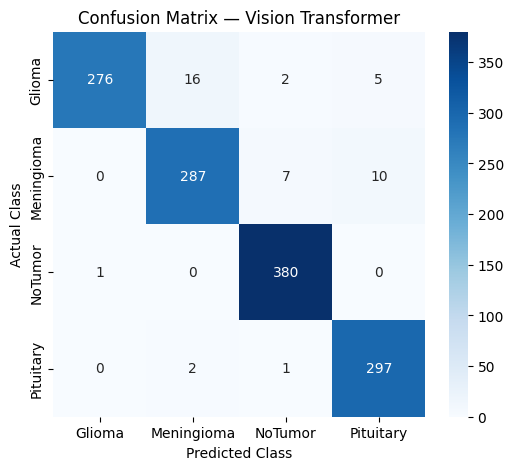


Detailed Classification Report:
              precision    recall  f1-score   support

      Glioma       1.00      0.92      0.96       299
  Meningioma       0.94      0.94      0.94       304
     NoTumor       0.97      1.00      0.99       381
   Pituitary       0.95      0.99      0.97       300

    accuracy                           0.97      1284
   macro avg       0.97      0.96      0.96      1284
weighted avg       0.97      0.97      0.97      1284



In [54]:
# ============================================================
# STEP — Evaluate Vision Transformer on Test Set
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load saved ViT model
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.IMAGENET1K_V1
vit_model = vit_b_16(weights=weights)

vit_model.heads.head = torch.nn.Linear(
    vit_model.heads.head.in_features, 4
)

vit_model.load_state_dict(
    torch.load("vit_b16_model.pth", map_location=device)
)

vit_model = vit_model.to(device)
vit_model.eval()

print("Vision Transformer model loaded successfully.")

# ===============================
# Evaluation
# ===============================

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = vit_model(images)

        probs = F.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# ===============================
# Metrics
# ===============================

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")
f1 = f1_score(all_labels, all_preds, average="macro")
roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")

print("\n===== VISION TRANSFORMER TEST PERFORMANCE =====")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1-Score (Macro): {f1:.4f}")
print(f"ROC-AUC (OvR): {roc_auc:.4f}")


# ===============================
# Confusion Matrix Heatmap
# ===============================

cm = confusion_matrix(all_labels, all_preds)

class_names = ["Glioma", "Meningioma", "NoTumor", "Pituitary"]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix — Vision Transformer")

plt.show()


# ===============================
# Classification Report
# ===============================

print("\nDetailed Classification Report:")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

---

## Vision Transformer (ViT-B/16) Model — Key Findings

- **Strong overall performance:** The Vision Transformer achieved **96.57% test accuracy**, indicating effective learning of tumor classification patterns from MRI images.

- **Balanced multi-class performance:** A **macro F1-score of 0.9643** shows that the model maintains reasonably consistent performance across all tumor classes.

- **High class separability:** The **ROC-AUC score of 0.9978** demonstrates that the model can effectively distinguish between tumor categories.

- **Excellent detection of non-tumor images:** The confusion matrix shows **380 correct predictions for the NoTumor class**, indicating near-perfect identification of healthy brain scans.

- **Reliable pituitary tumor detection:** The model correctly classified **297 pituitary images**, showing strong capability in recognizing this tumor type.

- **Moderate confusion between glioma and meningioma:** Some **glioma samples were misclassified as meningioma (16 cases)** and a few as pituitary, suggesting visual similarity between these tumor types in MRI scans.

- **Transformer-based global feature learning:** The Vision Transformer captures **global image relationships through self-attention**, which helps analyze spatial dependencies in MRI images.

---

## Vision Transformer — Limitation

Although the Vision Transformer performs well, its accuracy is slightly lower than EfficientNet and DenseNet because **transformer models typically require larger datasets to fully exploit their attention-based architecture**, making them less efficient than CNNs for moderate-sized medical imaging datasets.

---
---

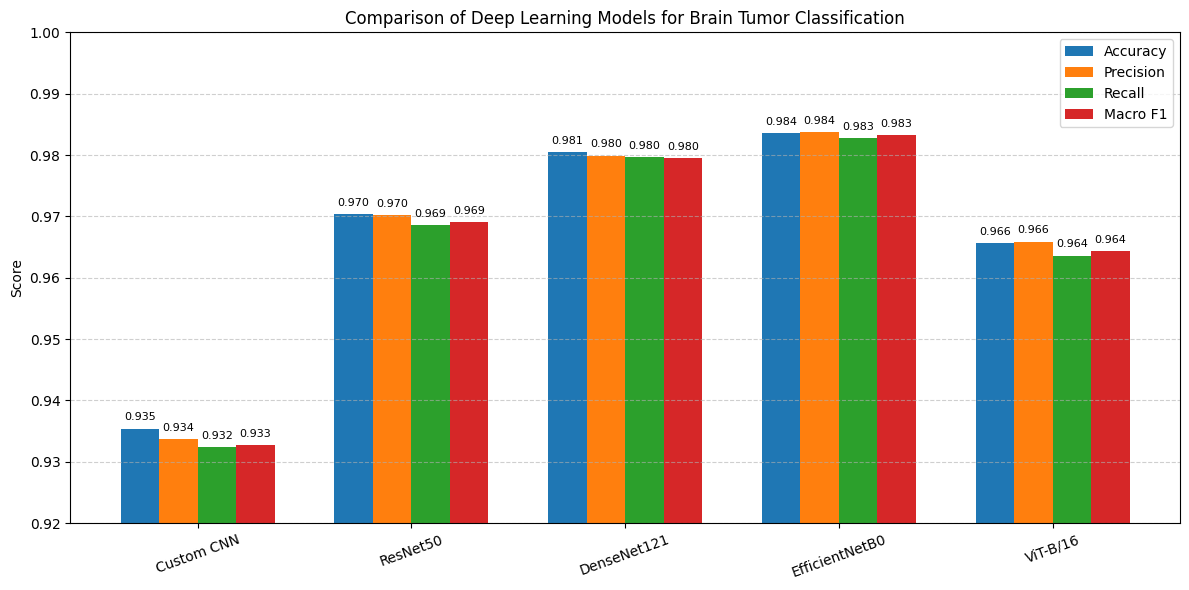

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = [
    "Custom CNN",
    "ResNet50",
    "DenseNet121",
    "EfficientNetB0",
    "ViT-B/16"
]

# Metrics
accuracy = [0.9354, 0.9704, 0.9805, 0.9836, 0.9657]
precision = [0.9337, 0.9702, 0.9799, 0.9838, 0.9659]
recall = [0.9324, 0.9686, 0.9797, 0.9828, 0.9636]
f1 = [0.9327, 0.9690, 0.9795, 0.9833, 0.9643]

x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(12,6))

bars1 = plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
bars2 = plt.bar(x - 0.5*width, precision, width, label="Precision")
bars3 = plt.bar(x + 0.5*width, recall, width, label="Recall")
bars4 = plt.bar(x + 1.5*width, f1, width, label="Macro F1")

plt.xticks(x, models, rotation=20)
plt.ylabel("Score")
plt.title("Comparison of Deep Learning Models for Brain Tumor Classification")

plt.ylim(0.92,1.0)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add values above bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + 0.001,
                 f"{height:.3f}",
                 ha='center',
                 va='bottom',
                 fontsize=8)

plt.tight_layout()
plt.show()

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import torch.nn.functional as F
import numpy as np

def evaluate_model(model, test_loader, device):
    
    all_preds = []
    all_labels = []
    all_probs = []

    model.eval()

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")
    f1 = f1_score(all_labels, all_preds, average="macro")
    roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")

    return accuracy, precision, recall, f1, roc_auc, all_labels, all_probs

In [66]:
acc, prec, rec, f1, auc_score, all_labels, custom_cnn_probs = evaluate_model(
    baseline_model, test_loader, device
)

print("Custom CNN AUC:", auc_score)

Custom CNN AUC: 0.9886368821362802


In [74]:
acc, prec, rec, f1, auc_score, _, resnet50_probs = evaluate_model(
    resnet_model, test_loader, device
)

print("ResNet50 AUC:", auc_score)

ResNet50 AUC: 0.9981678651816193


In [69]:
acc, prec, rec, f1, auc_score, all_labels, densenet121_probs = evaluate_model(
    model, test_loader, device
)

print("DenseNet121 AUC:", auc_score)

DenseNet121 AUC: 0.9995375681453286


In [71]:
acc, prec, rec, f1, auc_score, _, efficientnet_probs = evaluate_model(
    model, test_loader, device
)

print("EfficientNetB0 AUC:", auc_score)

EfficientNetB0 AUC: 0.9995375681453286


In [72]:
acc, prec, rec, f1, auc_score, _, vit_probs = evaluate_model(
    vit_model, test_loader, device
)

print("Vision Transformer AUC:", auc_score)

Vision Transformer AUC: 0.9978099837317583


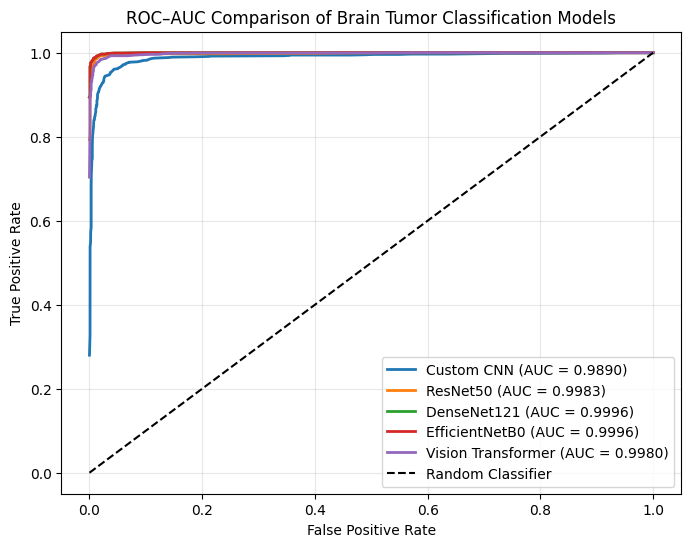

In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Number of classes
n_classes = 4

# Convert labels to binary format
y_test_bin = label_binarize(all_labels, classes=[0,1,2,3])

# Store probabilities for each model
model_probs = {
    "Custom CNN": custom_cnn_probs,
    "ResNet50": resnet50_probs,
    "DenseNet121": densenet121_probs,
    "EfficientNetB0": efficientnet_probs,
    "Vision Transformer": vit_probs
}

plt.figure(figsize=(8,6))

for model_name, probs in model_probs.items():

    fpr = dict()
    tpr = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])

    # Compute macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes

    roc_auc_macro = auc(all_fpr, mean_tpr)

    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc_macro:.4f})"
    )

# Random classifier baseline
plt.plot([0,1],[0,1],'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Comparison of Brain Tumor Classification Models")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

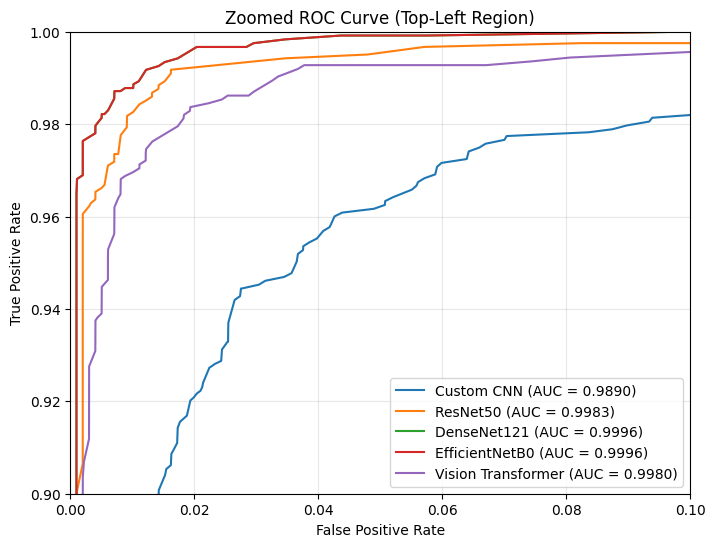

In [76]:
plt.figure(figsize=(8,6))

for model_name, probs in model_probs.items():

    fpr = dict()
    tpr = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes

    roc_auc_macro = auc(all_fpr, mean_tpr)

    plt.plot(all_fpr, mean_tpr,
             label=f"{model_name} (AUC = {roc_auc_macro:.4f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Zoomed ROC Curve (Top-Left Region)")

# ZOOM AREA
plt.xlim(0,0.1)
plt.ylim(0.9,1.0)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

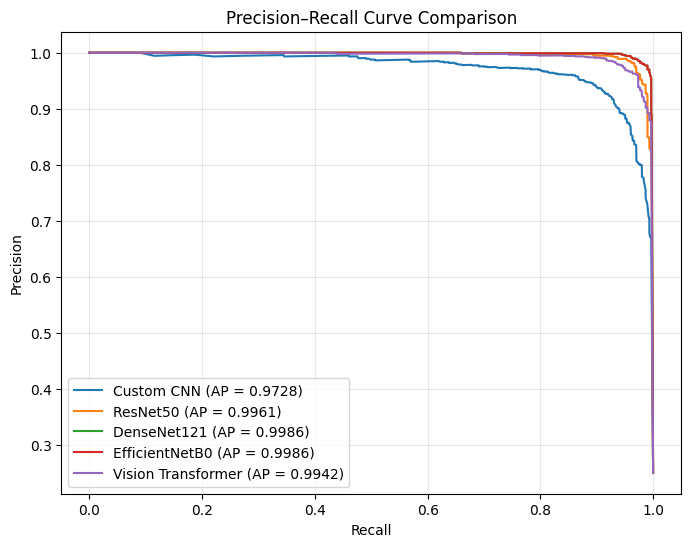

In [79]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))

for model_name, probs in model_probs.items():
    
    precision = dict()
    recall = dict()

    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(
            y_test_bin[:, i], probs[:, i]
        )

    all_recall = np.unique(np.concatenate([recall[i] for i in range(n_classes)]))
    
    mean_precision = np.zeros_like(all_recall)
    for i in range(n_classes):
        mean_precision += np.interp(all_recall, recall[i][::-1], precision[i][::-1])

    mean_precision /= n_classes

    ap_score = average_precision_score(y_test_bin, probs, average="macro")

    plt.plot(all_recall, mean_precision,
             label=f"{model_name} (AP = {ap_score:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.show()